In [1]:
import pandas as pd
from pathlib import Path
import json
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import MaxNLocator, ScalarFormatter
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import skew, kurtosis

colors = ["#F0741E", "#276CB3"]

plt.style.use("seaborn-v0_8-paper")

save_path=Path("./plots")
save_path.mkdir(exist_ok=True, parents=True)

In [2]:
def get_num_atoms(file_xyz):
    try:
        with open(file_xyz, 'r') as file:
            first_line = file.readline()
            n_atoms = int(first_line.strip())
            return n_atoms
    except Exception as e:
        print(f"Error: {e}")
        return None

In [3]:
names = []
n_electrons = []
n_atoms = []
fermi = []
total_energy = []
IP =[]
EA =[]
bang_gap = []
total_energy_plus = []
total_energy_minuns = []
current = []
batch_id = []

xyz_files_path = Path("/home/mario/jobs/git_folders/AutoDFTB/test_xyz")

batches = [2]
for batch in batches:
    dataset = Path(f"/home/mario/jobs/git_folders/AutoDFTB/test_batch")

    dftb_files = [f for f in dataset.joinpath("dftb","json_files").iterdir() if f.suffix.lower() ==".json"]
    print(dftb_files)
    for file in tqdm(dftb_files):
        print(file)
        with open(str(file),"r") as f:
            data = json.load(f)

        try:
            with open(str(dataset.joinpath("transport","transport_output",f"{data['file_name'][:-4]}_e.json")),"r") as f:
                data_current = json.load(f)
                print("data_current", data_current)
            current.append(data_current["current"])
            
        except:
            continue
        print("data", data)
        names.append(data["file_name"][:-4])
        n_electrons.append(data["n_electrons"])
        fermi.append(data["fermi_level_ev"])
        total_energy.append(data["total_energy_eV"])
        IP.append(data["EA_ev"])
        EA.append(data["IP_ev"])
        bang_gap.append(data["band_gap_ev"])
        total_energy_plus.append(data["total_energy_eV_+1"])
        total_energy_minuns.append(data["total_energy_eV_-1"])
        batch_id.append(batch)
        
        n_atoms.append(get_num_atoms(xyz_files_path.joinpath(data["file_name"][:-4]+".xyz")))
    
        
    
df = pd.DataFrame({"file_name": names, "num_atoms":n_atoms, "total_energy": total_energy, "num_electrons": n_electrons, "Fermi_energy": fermi, "electron_affinity": EA, "ionization_potential": IP, "band_gap": bang_gap, "total_energy+1": total_energy_plus, "total_energy-1": total_energy_minuns, "current":current, "batch": batch_id})
df.to_csv("./dataset.csv", index=False)

[PosixPath('/home/mario/jobs/git_folders/AutoDFTB/test_batch/dftb/json_files/graphene_1982_opt.json'), PosixPath('/home/mario/jobs/git_folders/AutoDFTB/test_batch/dftb/json_files/graphene_3467_opt.json')]


100%|██████████| 2/2 [00:00<00:00, 51.05it/s]

/home/mario/jobs/git_folders/AutoDFTB/test_batch/dftb/json_files/graphene_1982_opt.json
data_current {'file_name': 'graphene_1982_e', 'current': 9.39111e-07, 'atoms_device': [1, 395], 'atoms_source': [396, 491], 'atoms_drain': [492, 587], 'transport_cell': [65.0, 0.0, 0.0, 0.0, 34.27629786, 0.0, 0.0, 0.0, 40.0], 'contact_vector': [7.409367073373903, 0.0, 0.0], 'potential_source': 0.05, 'potential_drain': -0.05, 'energy_range': [-5.168186932625822, -4.168186933489892], 'energy_step': 0.01, 'fermi_temperature': 0.0, 'fermi_energy_source': -4.668186933489892, 'fermi_energy_drain': -4.668186932625822, 'LDOS': {'region1': {'energy': [-5.168187, -5.158187, -5.148187, -5.138187, -5.128187, -5.118187, -5.108187, -5.098187, -5.088187, -5.078187, -5.068187, -5.058187, -5.048187, -5.038187, -5.028187, -5.018187, -5.008187, -4.998187, -4.988187, -4.978187, -4.968187, -4.958187, -4.948187, -4.938187, -4.928187, -4.918187, -4.908187, -4.898187, -4.888187, -4.878187, -4.868187, -4.858187, -4.848187, 

In [4]:
# dataset = Path(f"/home/tommaso/git_workspace/AutoDFTB/data_batch_{batch}")

# dftb_files = [f for f in dataset.joinpath("dftb","json_files").iterdir() if f.suffix.lower() ==".json"]
# current_files = [f for f in dataset.joinpath("transport","transport_output").iterdir() if f.suffix.lower() ==".json"]

# print(len(dftb_files))
# print(len(current_files))

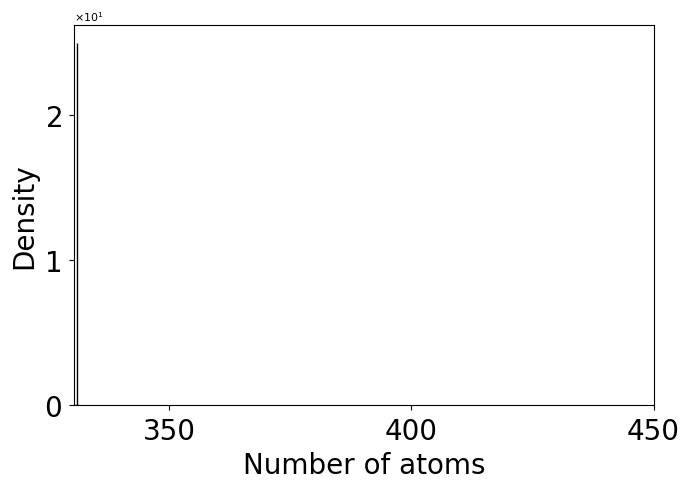

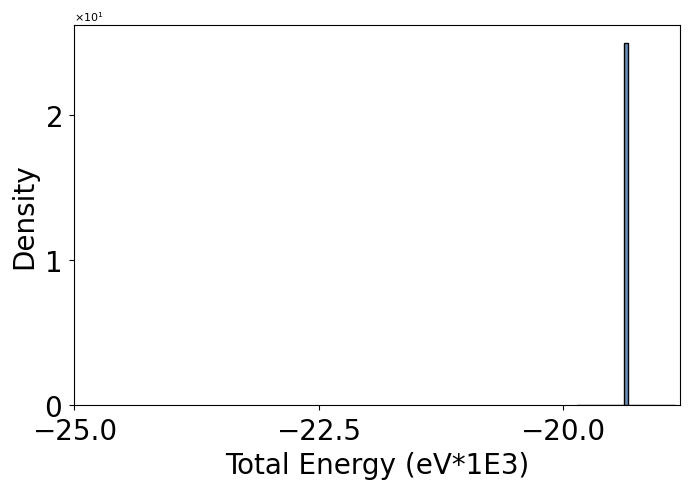

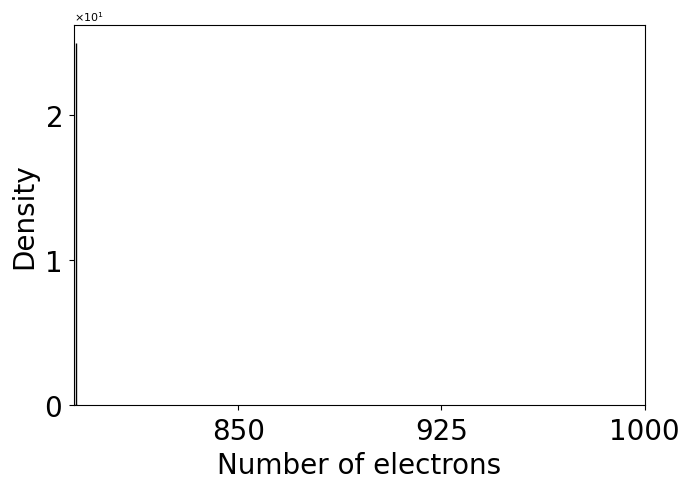

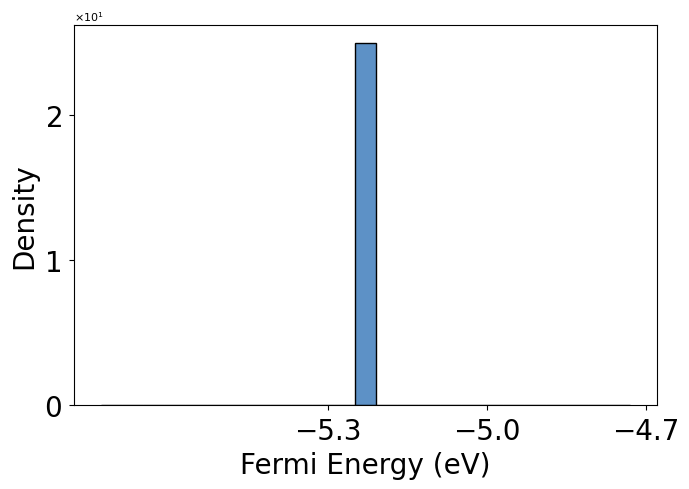

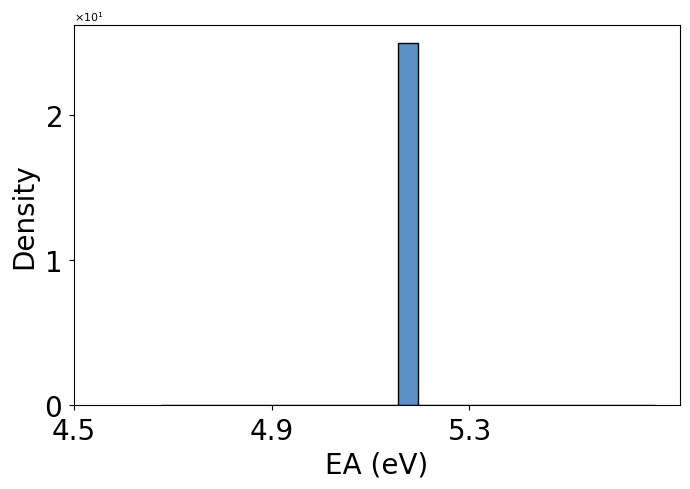

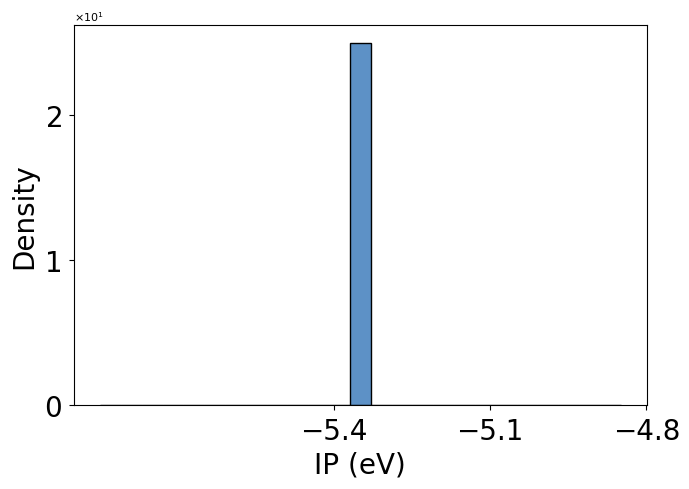

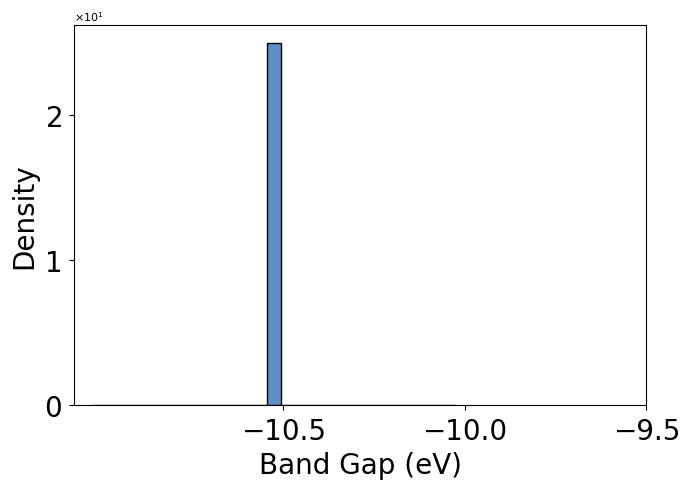

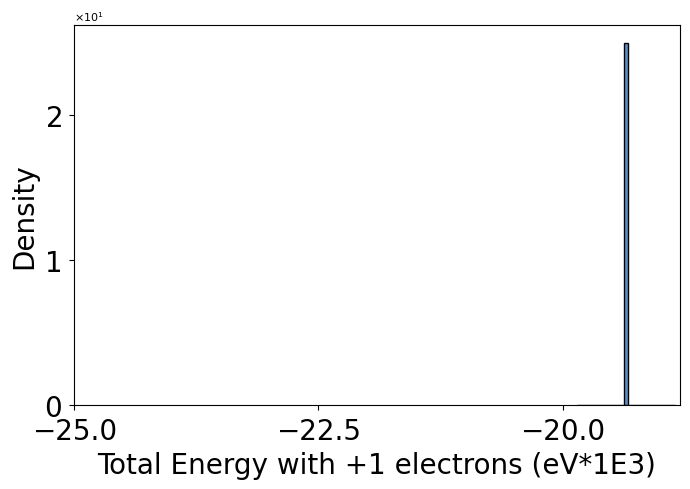

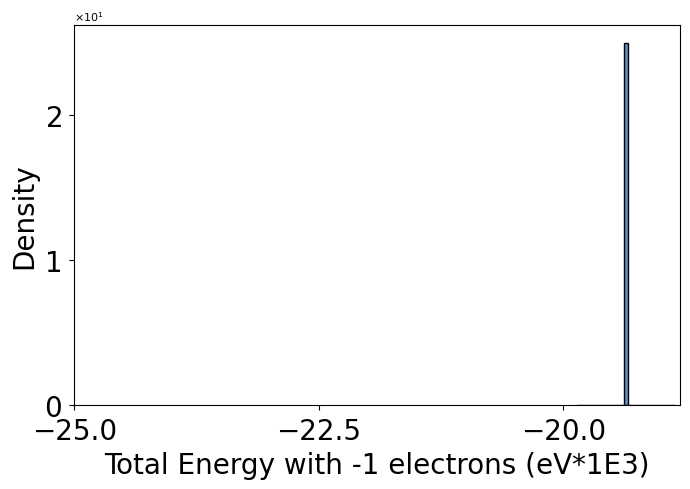

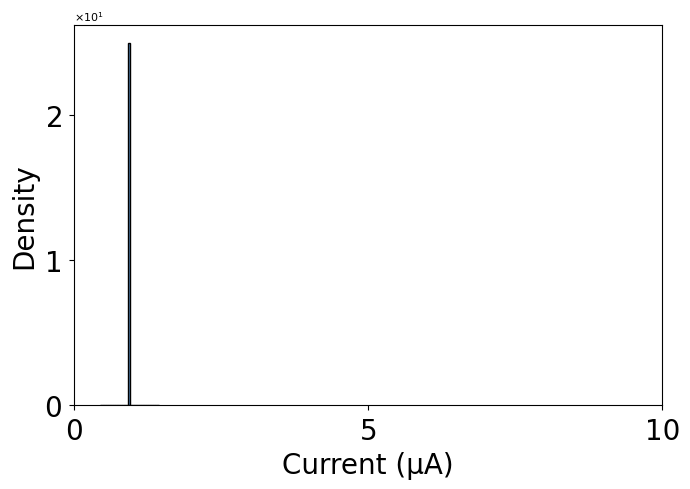

In [4]:
target_list = ["num_atoms","total_energy", "num_electrons", "Fermi_energy", "electron_affinity", "ionization_potential", "band_gap", "total_energy+1", "total_energy-1", "current"]
target_labels = {
    "num_atoms": ("Number of atoms", "Density"),
    "total_energy": ("Total Energy (eV*1E3)", "Density"),
    "num_electrons": (
        "Number of electrons",
        "Density",
    ),
    "Fermi_energy": ("Fermi Energy (eV)", "Density"),
    "electron_affinity": (
        "EA (eV)",
        "Density",
    ),
    "ionization_potential": (
        "IP (eV)",
        "Density",
    ),
    "band_gap": (
        "Band Gap (eV)",
        "Density",
    ),
    "total_energy+1": (
        "Total Energy with +1 electrons (eV*1E3)",
        "Density",
    ),
    "total_energy-1": (
        "Total Energy with -1 electrons (eV*1E3)",
        "Density",
    ),
    "current": (
        "Current (µA)",
        "Density",
    ),
}

target_ticks = {
    "num_atoms" : [350, 400, 450],
    "total_energy": [-25,-22.5,-20],
    "num_electrons": [850, 925, 1000],
    "Fermi_energy": [-5.3, -5.0, -4.7],
    "electron_affinity": [4.5, 4.9, 5.3],
    "ionization_potential": [-5.4, -5.1, -4.8],
    "band_gap": [-10.5, -10.0, -9.5],
    "total_energy+1": [-25,-22.5,-20],
    "total_energy-1": [-25,-22.5,-20],
    "current": [0,5,10],
}
df = pd.read_csv("./dataset.csv", header=0)

for target in target_list:
    
    if target == "current":
        df["current"] = df["current"]*1000000
    elif target == "total_energy":
        df["total_energy"] = df["total_energy"]/1000
    elif target == "total_energy+1":
        df["total_energy+1"] = df["total_energy+1"]/1000
    elif target == "total_energy-1":
        df["total_energy-1"] = df["total_energy-1"]/1000

    fig = plt.figure(figsize=(7, 5))

    ax = fig.add_subplot(1, 1, 1)  # Aggiungi subplot

    sns.histplot(
        x=df[f"{target}"],
        fill=True,
        linewidth=1,
        kde=False,
        stat="density",
        color=colors[1],
        ax=ax,
        bins=25 #int(np.sqrt(len(df[f"{target}"]))),
    )
    # sns.kdeplot(x=df[f"{target}"].to_numpy(), linewidth=2, color=colors[0], ax=ax)
    
    # Impostare i ticks in formato esponenziale
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-1,1))

    #ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

    # ax.xaxis.set_major_locator(
    #     MaxNLocator(nbins=3)
    # )  # Imposta massimo 3 ticks sull'asse x
    ax.set_xticks(target_ticks[target])
    ax.yaxis.set_major_locator(
        MaxNLocator(nbins=3)
    )  # Imposta massimo 3 ticks sull'asse y
    ax.set_xlabel(target_labels[target][0], fontsize=20)
    ax.set_ylabel(target_labels[target][1], fontsize=20)
    plt.tick_params(axis="both", which="major", labelsize=20)
    plt.tight_layout()
    plt.savefig(
        save_path.joinpath(f"{target}.png"), dpi=300, bbox_inches="tight"
    )

/home/mario/miniconda3/envs/stm/lib/python3.10/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/home/mario/miniconda3/envs/stm/lib/python3.10/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/home/mario/miniconda3/envs/stm/lib/python3.10/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/home/mario/miniconda3/envs/stm/lib/python3.10/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/home/mario/miniconda3/envs/stm/lib/python3.10/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/home/mario/minicond

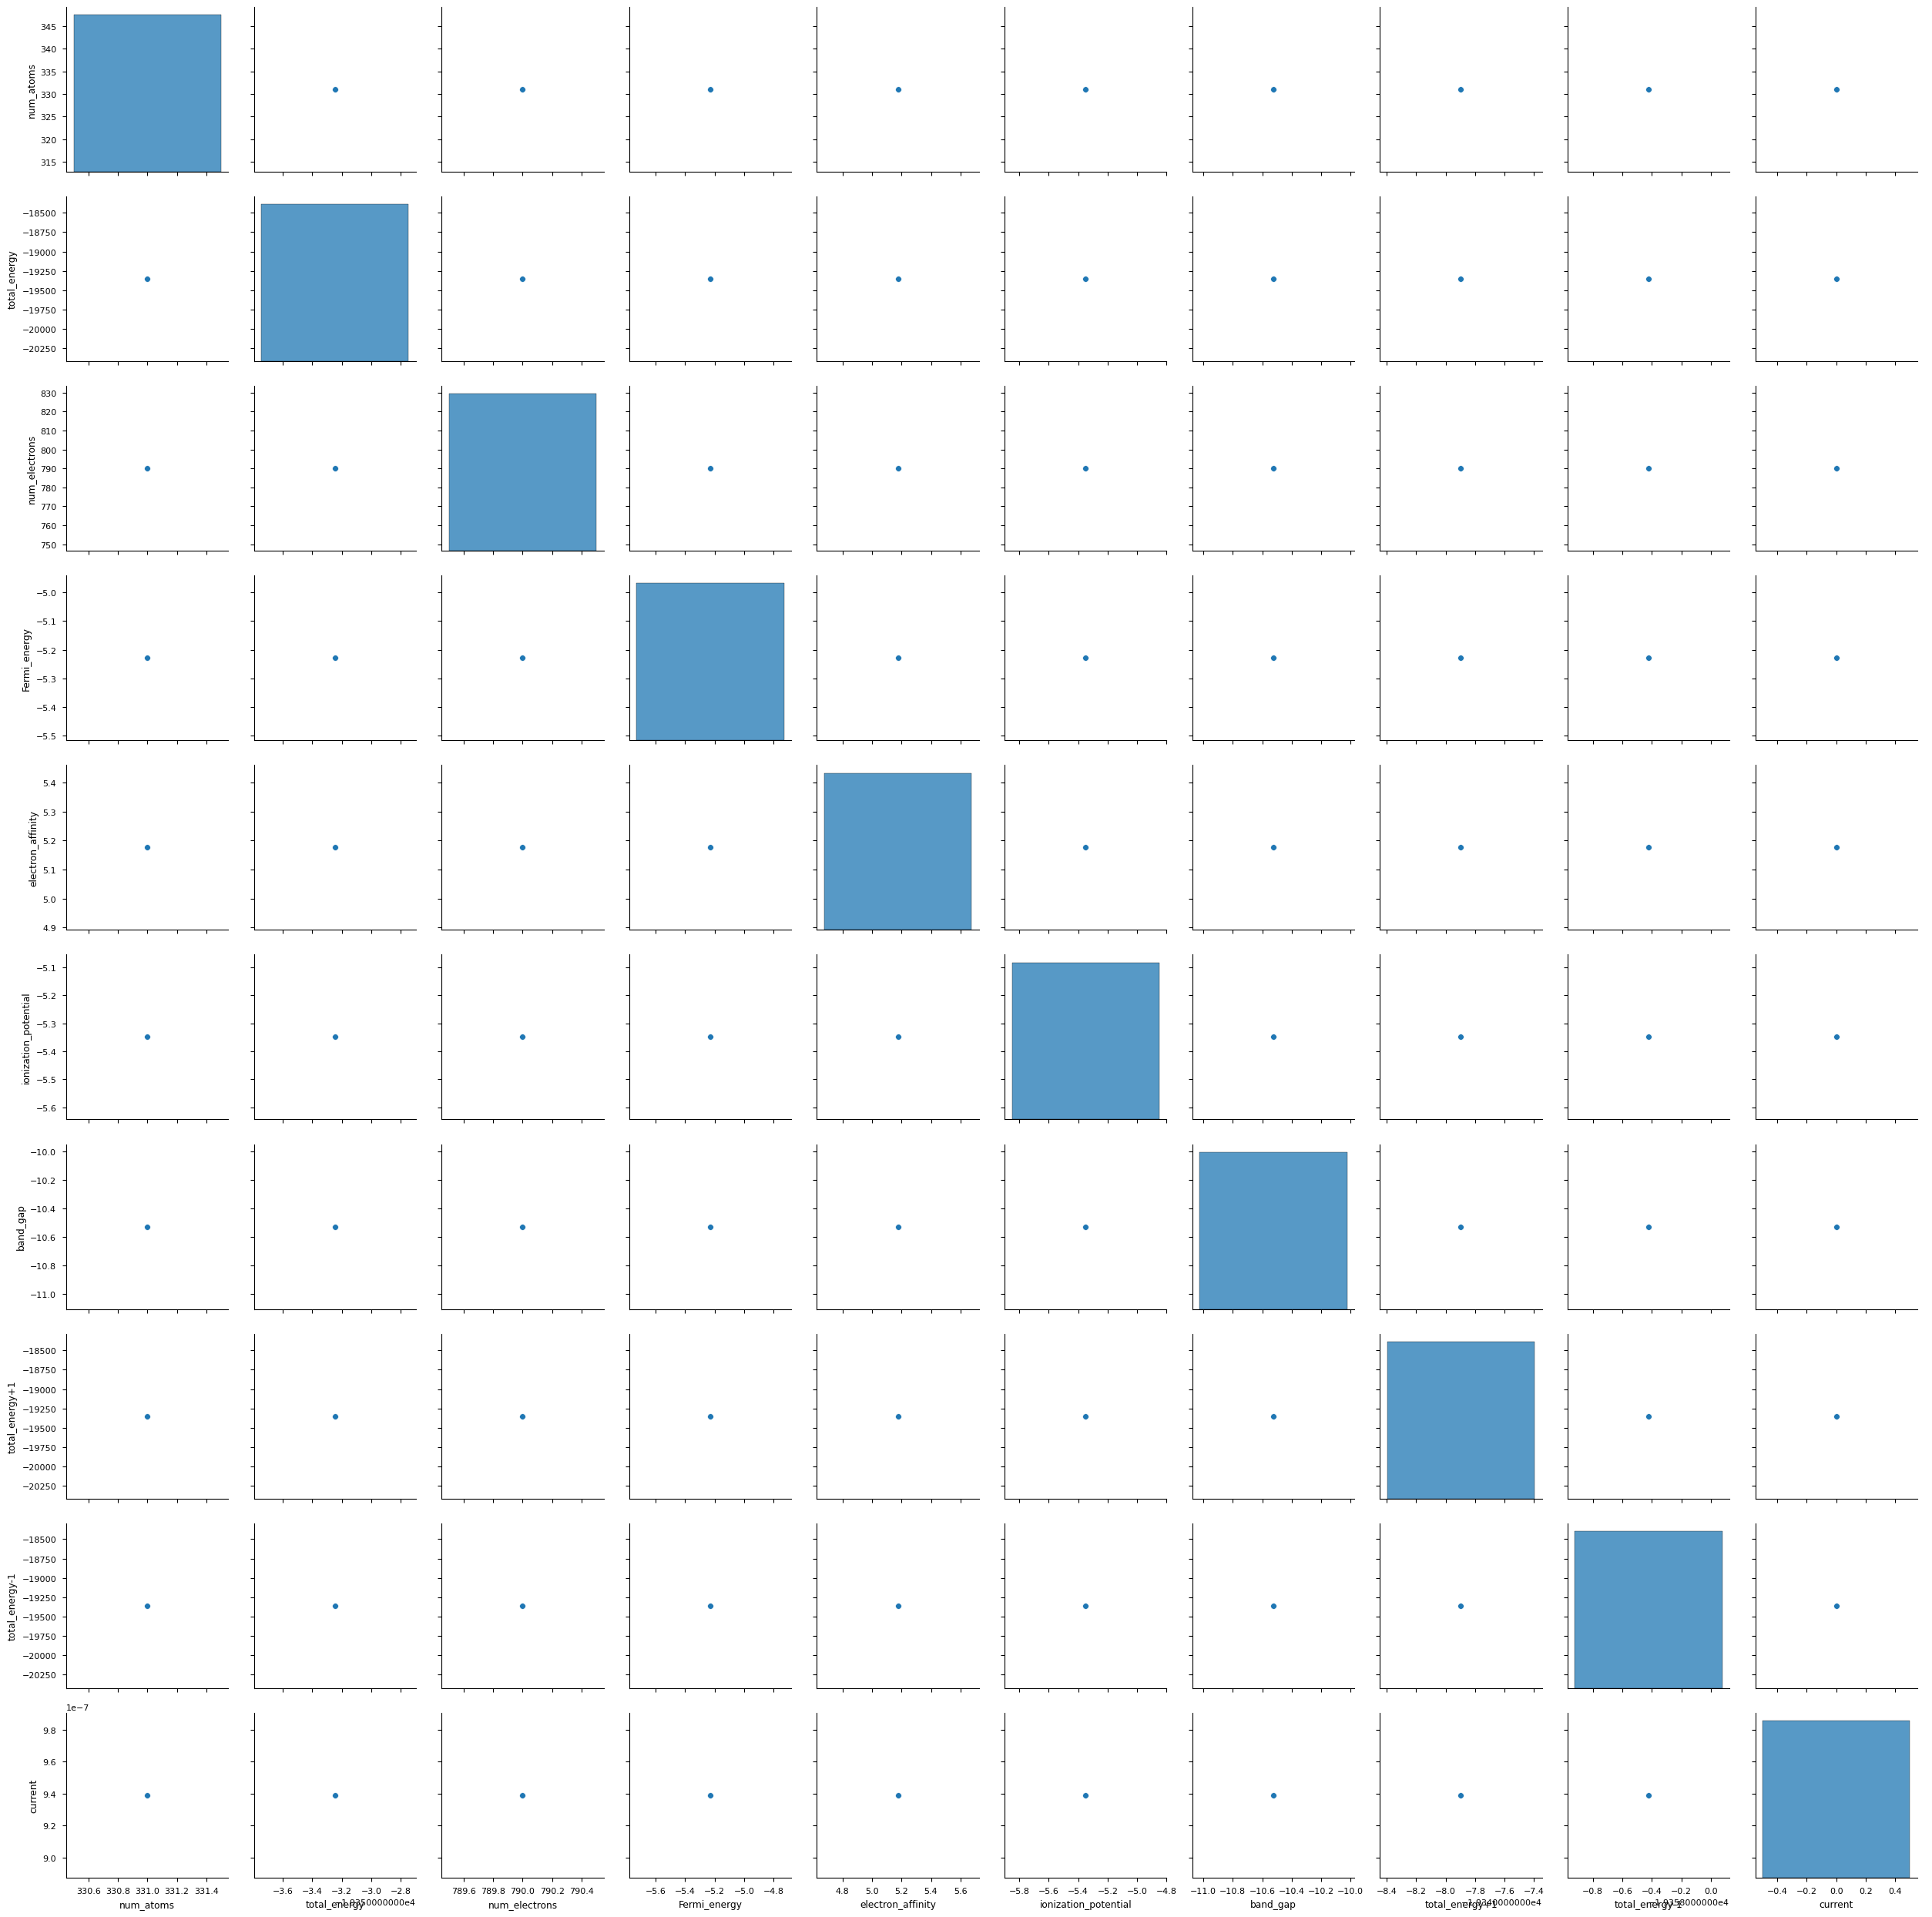

In [5]:
features_list = ["num_atoms","total_energy", "num_electrons", "Fermi_energy", "electron_affinity", "ionization_potential", "band_gap", "total_energy+1", "total_energy-1", "current"]
df = pd.read_csv("./dataset.csv", header=0)

pair_grid = sns.PairGrid(
    df, palette="tab10", vars=features_list
)  # Limita a prime 5 features per chiarezza
pair_grid.map_diag(sns.histplot)
pair_grid.map_offdiag(sns.scatterplot)
pair_grid.add_legend()
plt.tight_layout()
plt.savefig(
    save_path.joinpath("pairplot.png"), dpi=300, bbox_inches="tight"
)

In [6]:
df = pd.read_csv('./dataset.csv')

df.drop(
        ["file_name"], axis=1, inplace=True
    )

df["current"] = df["current"]*1000000

# Crea un dizionario per conservare i risultati
statistics = {
    'Mean': df.mean(),
    'Standard Deviation': df.std(),
    'Max': df.max(),
    'Min': df.min(),
    'Median': df.median(),
    '3rd Moment (Skewness)': df.apply(lambda x: skew(x.dropna())),
    '4th Moment (Kurtosis)': df.apply(lambda x: kurtosis(x.dropna(), fisher=False))
}

# Converti il dizionario in un DataFrame per visualizzare meglio i risultati
stats_df = pd.DataFrame(statistics)

# Stampa i risultati
print(stats_df)

                              Mean  Standard Deviation           Max  \
num_atoms               331.000000                 NaN    331.000000   
total_energy         -19353.246000                 NaN -19353.246000   
num_electrons           790.000000                 NaN    790.000000   
Fermi_energy             -5.228800                 NaN     -5.228800   
electron_affinity         5.176000                 NaN      5.176000   
ionization_potential     -5.349300                 NaN     -5.349300   
band_gap                -10.525300                 NaN    -10.525300   
total_energy+1       -19347.896700                 NaN -19347.896700   
total_energy-1       -19358.422000                 NaN -19358.422000   
current                   0.939111                 NaN      0.939111   
batch                     2.000000                 NaN      2.000000   

                               Min        Median  3rd Moment (Skewness)  \
num_atoms               331.000000    331.000000            